# This notebook shows how to integrate any custom model with the Hugging Face transformers 

In [ ]:
%pip install datasets transformers matplotlib torch

## 1. Firstly we need to define the base architecture of the model
We start by implementing the base architecture of a vanilla Variational Autoencoder (VAE). This model consists of two main components:

- Encoder: A convolutional neural network that processes the input image and compresses it into a lower-dimensional latent representation. It outputs two vectors: the mean (mu) and the log-variance (logvar), which define the parameters of the latent Gaussian distribution.

- Decoder: A transposed convolutional neural network that reconstructs the image from a latent vector sampled from the Gaussian distribution defined by the encoder.

The model follows a standard VAE structure, using convolutional layers for encoding and transposed convolutions for decoding, suitable for handling image data. The reparameterization trick is applied between encoder and decoder to allow backpropagation through the sampling step.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class BaseVAE(nn.Module):
    def __init__(self, latent_dim=16):
        super(BaseVAE, self).__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(128 * 4 * 4, latent_dim)

        self.decoder_input = nn.Linear(latent_dim, 128 * 4 * 4)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x = self.decoder_input(z)
        x = x.view(-1, 128, 4, 4)
        return self.decoder(x)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

## 2. Now we need to integrate our custom model with the transformers library
To make our custom VAE model compatible with the Hugging Face ecosystem, we define two key components:

- VAEConfig: This class inherits from PretrainedConfig and holds the hyperparameters and configuration of the model. For now, it includes the latent_dim parameter, which specifies the size of the latent space, but it can be extended with additional parameters as needed.

- VAEModel: This class inherits from PreTrainedModel and wraps around the base architecture (BaseVAE). It handles the forward pass and provides methods like encode and decode to expose key functionality of the underlying VAE. Importantly, by subclassing PreTrainedModel, we enable the use of Hugging Face’s save_pretrained and from_pretrained methods, allowing the model to be easily saved, loaded, and shared via the Hugging Face Hub.

In [2]:
from transformers import PreTrainedModel, PretrainedConfig


class VAEConfig(PretrainedConfig):
    model_type = "vae"

    def __init__(self, latent_dim=16, **kwargs):
        super().__init__(**kwargs)
        self.latent_dim = latent_dim

class VAEModel(PreTrainedModel):
    config_class = VAEConfig

    def __init__(self, config):
        super().__init__(config)
        self.vae = BaseVAE(latent_dim=config.latent_dim)
        self.post_init()

    def forward(self, x):
        return self.vae(x)

    def encode(self, x):
        return self.vae.encode(x)

    def decode(self, z):
        return self.vae.decode(z)

e:\biomike\AI-Workshop-HuggingFace\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Training the custom model

### 3.1 Define the hyperparameters
In this step, we specify the key hyperparameters that will control the training process and the architecture of the model:

- batch_size: Defines the number of samples processed together in one forward/backward pass. A batch size of 64 is a common choice that balances training speed and GPU memory usage.

- epochs: The total number of passes through the entire training dataset. We set it to 25, which provides enough iterations to observe meaningful learning while keeping training time manageable.

- lr (learning rate): The step size used by the optimizer to update the model's weights. A value of 4e-3 is relatively high but suitable for small models like this VAE, promoting faster convergence.

- latent_dim: Specifies the dimensionality of the latent space. A latent space of size 16 allows the model to capture compressed representations of the input data while remaining computationally efficient.

In [11]:
batch_size = 64
epochs = 250
lr = 4e-3
latent_dim = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### 3.2 Loading the dataset
We load the training dataset using the datasets library. In this case, we use the "valhalla/emoji-dataset", which provides a collection of emoji images suitable for image generation tasks.

Key steps in data preparation:

- Loading: We download and load the dataset using load_dataset(), which returns a dictionary-like object with splits (in this case, train).

- Transformations: We define a transform pipeline using torchvision.transforms to resize all images to 32×32 pixels and convert them into PyTorch tensors. This ensures uniform input size and format required by the model.

- Collation: A custom collate_fn is provided to apply the transformations to each sample in the batch and stack them into a single tensor.

- DataLoader: We use PyTorch's DataLoader to efficiently batch and shuffle the data during training. The batch_size is set as specified earlier, and shuffling ensures that each epoch sees the data in a different order.

In [5]:
from datasets import load_dataset
from torch.utils.data import DataLoader
import torchvision.transforms as T
from torch.optim import Adam
import matplotlib.pyplot as plt
import random

def collate_fn(batch):
    images = [transform(item["image"]) for item in batch]
    return torch.stack(images)


dataset = load_dataset("valhalla/emoji-dataset")

transform = T.Compose([
    T.Resize((32, 32)),
    T.ToTensor()
])

dataloader = DataLoader(dataset["train"], batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

### 3.3 Initialize the model and optimizer
In this step, we initialize the components required for training:

- Model configuration: We create an instance of VAEConfig, specifying the latent dimension (latent_dim). This config defines the architecture's key parameters.

- Model initialization: Using the config, we instantiate the VAEModel, which wraps around the base VAE architecture and is compatible with Hugging Face’s API.

- Device selection: We determine whether a GPU (cuda) is available and move the model to the appropriate device (GPU or CPU).

- Optimizer: We initialize the Adam optimizer with the model’s parameters and the previously defined learning rate (lr). Adam is a good default choice for training VAEs due to its adaptive learning rate capabilities.

- Loss function: We define the standard VAE loss, which combines two components:
    - Reconstruction loss: Measures how well the output image matches the input, using mean squared error (MSE).

    - KL divergence: Encourages the learned latent distribution to approximate a standard normal distribution, promoting good generative properties.

In [6]:
config = VAEConfig(latent_dim=latent_dim)
vae = VAEModel(config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = vae.to(device)

optimizer = Adam(vae.parameters(), lr=lr)

def loss_function(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kld


In [7]:
def show_reconstructions(model, dataset, transform, device):
    model.eval()
    indices = random.sample(range(len(dataset)), 10)
    fig, axes = plt.subplots(10, 2, figsize=(4, 20))

    with torch.no_grad():
        for i, idx in enumerate(indices):
            img = transform(dataset[idx]["image"]).unsqueeze(0).to(device)
            recon, _, _ = model(img)

            orig_img = img.squeeze(0).permute(1, 2, 0).cpu().numpy()
            recon_img = recon.squeeze(0).permute(1, 2, 0).cpu().numpy()

            axes[i, 0].imshow(orig_img)
            axes[i, 0].axis("off")
            axes[i, 0].set_title("Original")

            axes[i, 1].imshow(recon_img)
            axes[i, 1].axis("off")
            axes[i, 1].set_title("Reconstruction")

    plt.tight_layout()
    plt.show()
    model.train()

### 3.4 Training the model
We now train the VAE using the prepared dataset and initialized components. The training loop proceeds as follows:

- Epoch loop: For each epoch (out of the total number of epochs), we:

    - Iterate over the batches of data provided by the DataLoader.

    - Move the batch to the target device (GPU or CPU).

    - Zero the gradients to prevent accumulation from previous steps.

    - Perform a forward pass to get the reconstruction, mean (mu), and log-variance (logvar).

    - Compute the VAE loss (reconstruction + KL divergence).

    - Backpropagate the loss and update the model parameters.

    - Accumulate the total loss to monitor training progress.

- Logging: After each epoch, we print the average loss for that epoch, normalized by the dataset size.

- Visualization: Every 10 epochs, we call show_reconstructions(), which visualizes 10 random original images and their corresponding reconstructions. This helps monitor qualitative progress and verify that the model is learning to reconstruct images effectively.

In [8]:
vae.train()
for epoch in range(epochs):
    total_loss = 0
    for batch in dataloader:
        batch = batch.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = vae(batch)
        loss = loss_function(recon, batch, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(dataset['train'])}")

    if (epoch + 1) % 10 == 0:
        show_reconstructions(vae, dataset["train"], transform, device)

Epoch 1, Loss: 291.64018876182246
Epoch 2, Loss: 210.20297615326027
Epoch 3, Loss: 166.98673061511005
Epoch 4, Loss: 145.58833503376226
Epoch 5, Loss: 130.2271468744316


### 3.5 Saving and uploading the model
After training, we save the model and push it to the Hugging Face Hub using the save_pretrained method, push_to_hub=True ensures that the model is immediately uploaded to the Hub after saving locally.

In [ ]:
vae.save_pretrained("BioMike/emoji_vae", token="<hf_token>", push_to_hub=True)

e:\biomike\AI-Workshop-HuggingFace\.venv\Lib\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\mykha\.cache\huggingface\hub\models--BioMike--emoji_vae. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
model.safetensors: 100%|██████████| 1.73M/1.73M [00:01<00:00, 1.66MB/s]


## Inference
In this step, we demonstrate how to use the trained VAE model for inference. The process includes:

- Model loading: We load the trained model from Hugging Face Hub using VAEModel.from_pretrained(), ensuring it's placed on the correct device (GPU or CPU).

- Evaluation mode: We set the model to evaluation mode with vae.eval() to disable gradient computation and ensure deterministic behavior.

- Sampling: For 10 randomly selected samples from the dataset:

    - We display the original image.

    - We obtain the reconstruction by passing the image through the model.

    - We generate a new image from random noise by sampling a latent vector from the standard normal distribution and decoding it.

- Visualization: The results are shown in a 3-column layout:

    - Original input image.

    - Reconstructed image.

    - Image generated from random noise.

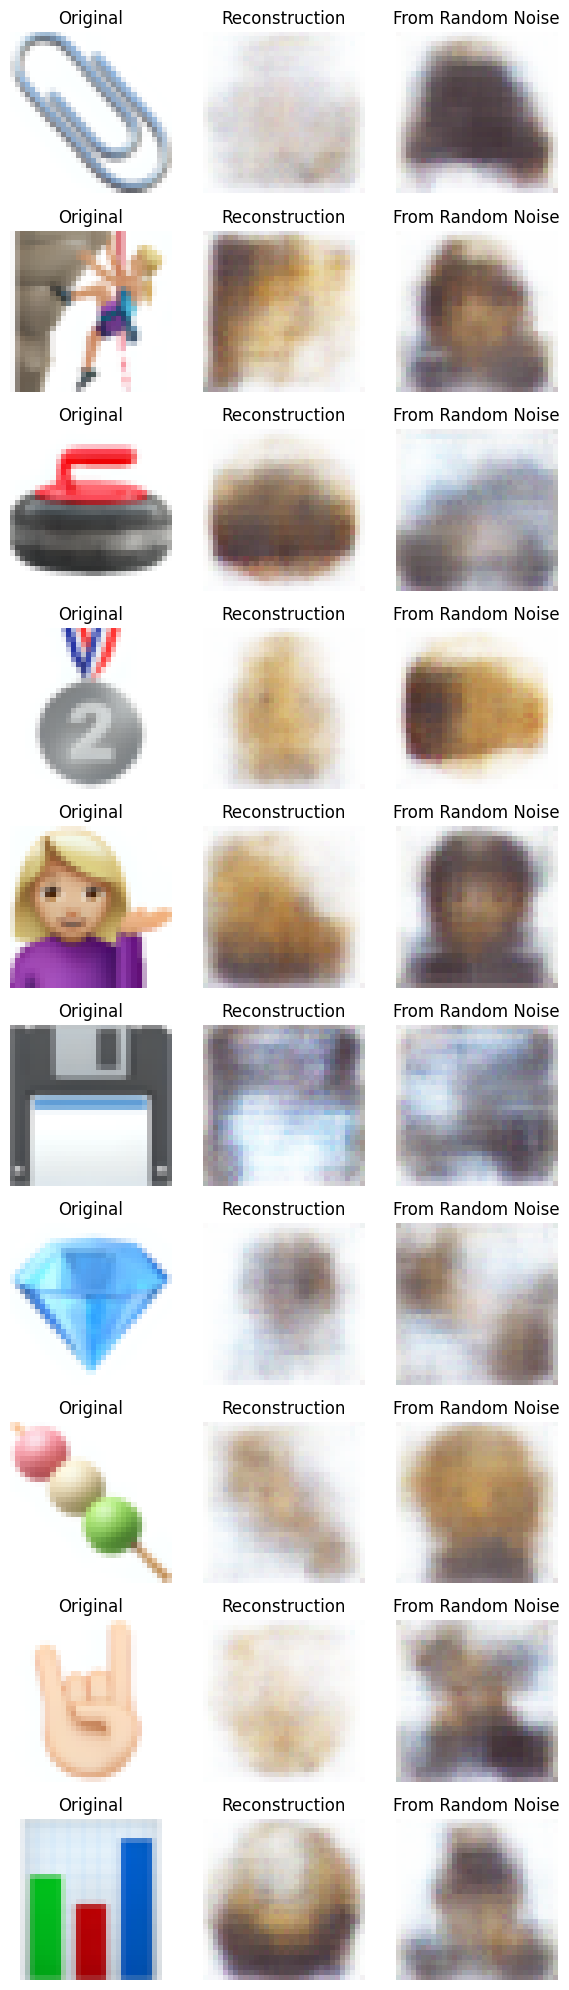

In [10]:
import matplotlib.pyplot as plt
import random

vae = VAEModel.from_pretrained("BioMike/emoji_vae")
vae = vae.to(device)

vae.eval()
n_samples = 10
indices = random.sample(range(len(dataset["train"])), n_samples)
latent_dim = vae.config.latent_dim

fig, axes = plt.subplots(n_samples, 3, figsize=(6, n_samples * 2))

for i, idx in enumerate(indices):
    example = dataset["train"][idx]
    image = transform(example["image"]).unsqueeze(0).to(device)
    
    with torch.no_grad():
        recon, mu, logvar = vae(image)

        z_random = torch.randn(1, latent_dim).to(device)
        

        generated = vae.decode(z_random)
    
    orig_img = image.squeeze(0).permute(1, 2, 0).cpu().numpy()
    recon_img = recon.squeeze(0).permute(1, 2, 0).cpu().numpy()
    gen_img = generated.squeeze(0).permute(1, 2, 0).cpu().numpy()
    
    axes[i, 0].imshow(orig_img)
    axes[i, 0].axis("off")
    axes[i, 0].set_title("Original")
    
    axes[i, 1].imshow(recon_img)
    axes[i, 1].axis("off")
    axes[i, 1].set_title("Reconstruction")
    
    axes[i, 2].imshow(gen_img)
    axes[i, 2].axis("off")
    axes[i, 2].set_title("From Random Noise")

plt.tight_layout()
plt.show()
